In [1]:
# importing libraries
import pandas as pd 
from datasets import load_dataset 
import matplotlib.pyplot as plt
import ast 
import seaborn as sns 

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

def clean_list(lists):
    if pd.notna(lists):
        return ast.literal_eval(lists)
df['job_skills'] = df['job_skills'].apply(clean_list)

/opt/anaconda3/envs/python_da/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_US = df[df['job_country'] == 'United States'].dropna(subset= ['salary_year_avg'])

In [3]:
job_list = df_US['job_title_short'].value_counts().index[:6].to_list()
df_US_top= df_US[df_US['job_title_short'].isin(job_list)]
job_order = df_US_top.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index[:6].to_list()

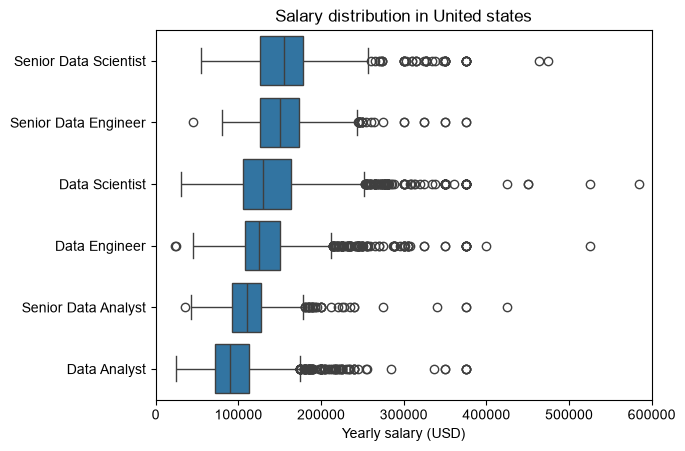

In [4]:
sns.boxplot(data= df_US_top, x= 'salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')
plt.title('Salary distribution in United states')
plt.xlabel('Yearly salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000)
plt.show()

In [21]:
df_US_DA = df_US[df_US['job_title_short'] == 'Data Analyst']
df_US_DA_exp = df_US_DA.explode('job_skills')
df_US_DA_exp_grp = df_US_DA_exp.groupby('job_skills')['salary_year_avg'].agg(['median', 'count'])


In [22]:
df_salary = df_US_DA_exp_grp.sort_values(by= 'median', ascending=False).head(10)
df_common = df_US_DA_exp_grp.sort_values(by= 'count', ascending=False).head(10)
df_common

,median,count
job_skills,,
sql,91000.00,2508
excel,84392.00,1808
python,97500.00,1431
tableau,92875.00,1364
sas,90000.00,926
r,92500.00,893
power bi,90000.00,838
powerpoint,85000.00,462
word,81194.75,461


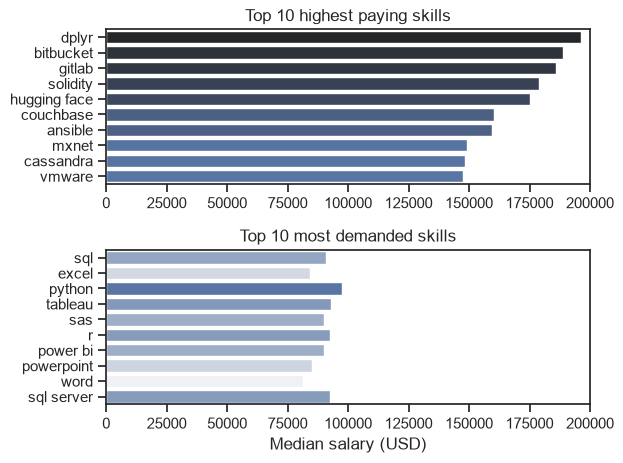

In [28]:
fig, ax = plt.subplots(2,1)
sns.set_theme(style='ticks')
# highest paying skills
sns.barplot(data=df_salary, x='median', y='job_skills', ax=ax[0], hue= 'median', palette= 'dark:b_r', legend=False )
ax[0].set_title('Top 10 highest paying skills')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].set_xlim(0, 200000)

# top demanded skills
sns.barplot(data=df_common, x='median', y='job_skills', ax=ax[1], hue= 'median', palette= 'light:b', legend=False )
ax[1].set_title('Top 10 most demanded skills')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median salary (USD)')
ax[1].set_xlim(0, 200000)
plt.tight_layout()
plt.show()
